In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
# Load the iris dataset
data = load_iris()
X = data.data
y = data.target

Accuracy: 1.00
|--- petal width (cm) <= 0.80
|   |--- class: 0
|--- petal width (cm) >  0.80
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- petal width (cm) <= 1.65
|   |   |   |   |--- class: 1
|   |   |   |--- petal width (cm) >  1.65
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- petal width (cm) <= 1.55
|   |   |   |   |--- class: 2
|   |   |   |--- petal width (cm) >  1.55
|   |   |   |   |--- sepal length (cm) <= 6.95
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- sepal length (cm) >  6.95
|   |   |   |   |   |--- class: 2
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- sepal width (cm) <= 3.10
|   |   |   |   |--- class: 2
|   |   |   |--- sepal width (cm) >  3.10
|   |   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



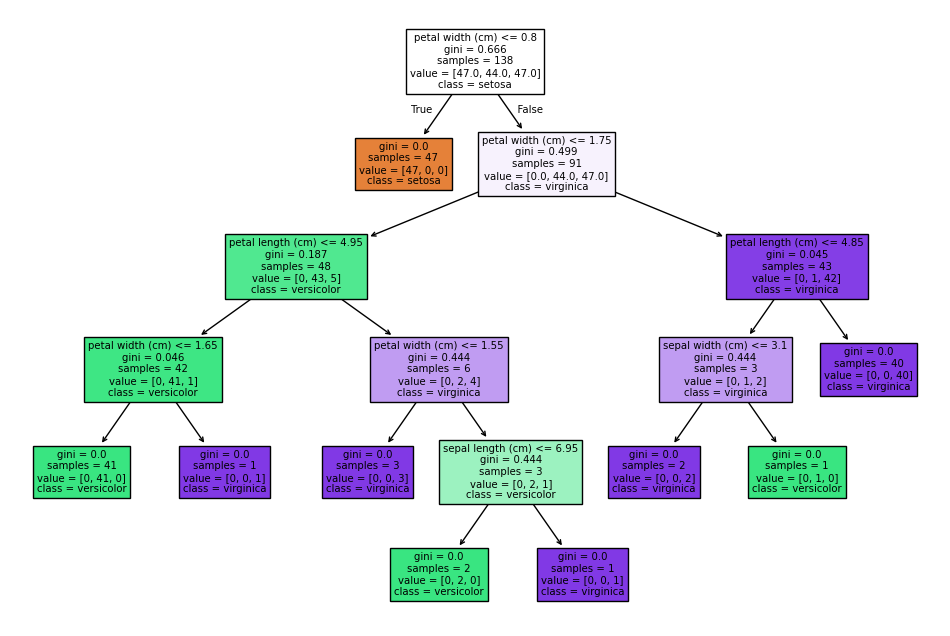

In [2]:
# lets split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.08, random_state=42)

# Create a Decision Tree Classifier
clf = DecisionTreeClassifier()

# Train the classifier
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# you can also see the structure of the decision tree
from sklearn.tree import export_text
tree_rules = export_text(clf, feature_names=data.feature_names)
print(tree_rules)

# as a image visualization
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(clf, feature_names=data.feature_names, class_names=data.target_names, filled=True)
plt.show()


In [3]:
# lets use grid search to find the best hyperparameters
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, scoring='accuracy')

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Score:", grid_search.best_score_)


Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 10}
Best Cross-validation Score: 0.9354497354497354


In [5]:
# You can use DT for regression tasks as well
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import load_diabetes
# Load the diabetes dataset
diabetes = load_diabetes()
df = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target
df.head(2)

# age: Age of the patient (in years).
# sex: Patient’s sex (Male/Female).
# bmi: Body Mass Index (a calculated value based on height and weight).
# bp: Blood Pressure (in mmHg – a crucial factor in diabetes management).
# s1: S1 (Blood Sugar Level - measured during a test).
# s2: S2 (Blood Sugar Level - measured later in the day).
# s3: S3 (Blood Sugar Level - measured during a test).
# s4: S4 (Blood Sugar Level - measured during a test).
# s5: S5 (Blood Sugar Level - measured during a test).
# s6: S6 (Blood Sugar Level - measured during a test).

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Create a Decision Tree Regressor
regressor = DecisionTreeRegressor()
# Train the regressor
regressor.fit(X_train, y_train)
# Make predictions
y_pred = regressor.predict(X_test)
# Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Mean Squared Error: 5637.07
R^2 Score: -0.06


In [6]:
# dataframe to visualize actual vs predicted
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
# add other relevant columns  from original dataset if needed
for col in X.columns:
    results[col] = X_test[col].values

results['Difference'] = results['Actual'] - results['Predicted']
results.head(10)


,Actual,Predicted,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Difference
287,219.0,190.0,0.045341,-0.044642,-0.006206,-0.015999,0.125019,0.125198,0.019187,0.034309,0.032432,-0.005220,29.0
211,70.0,166.0,0.092564,-0.044642,0.036907,0.021872,-0.024960,-0.016658,0.000779,-0.039493,-0.022517,-0.021788,-96.0
72,202.0,170.0,0.063504,0.050680,-0.004050,-0.012556,0.103003,0.048790,0.056003,-0.002592,0.084492,-0.017646,32.0
321,230.0,150.0,0.096197,-0.044642,0.051996,0.079265,0.054845,0.036577,-0.076536,0.141322,0.098648,0.061054,80.0
73,111.0,230.0,0.012648,0.050680,-0.020218,-0.002228,0.038334,0.053174,-0.006584,0.034309,-0.005142,-0.009362,-119.0
418,84.0,97.0,0.009016,-0.044642,-0.024529,-0.026328,0.098876,0.094196,0.070730,-0.002592,-0.021395,0.007207,-13.0
367,242.0,233.0,-0.009147,0.050680,0.170555,0.014987,0.030078,0.033759,-0.021311,0.034309,0.033654,0.032059,9.0
354,272.0,258.0,-0.023677,0.050680,0.045529,0.021872,0.109883,0.088873,0.000779,0.034309,0.074191,0.061054,14.0
281,94.0,179.0,-0.092695,0.050680,-0.090275,-0.057313,-0.024960,-0.030437,-0.006584,-0.002592,0.024055,0.003064,-85.0
148,96.0,197.0,-0.060003,0.050680,0.015350,-0.019442,0.036958,0.048164,0.019187,-0.002592,-0.030748,-0.001078,-101.0


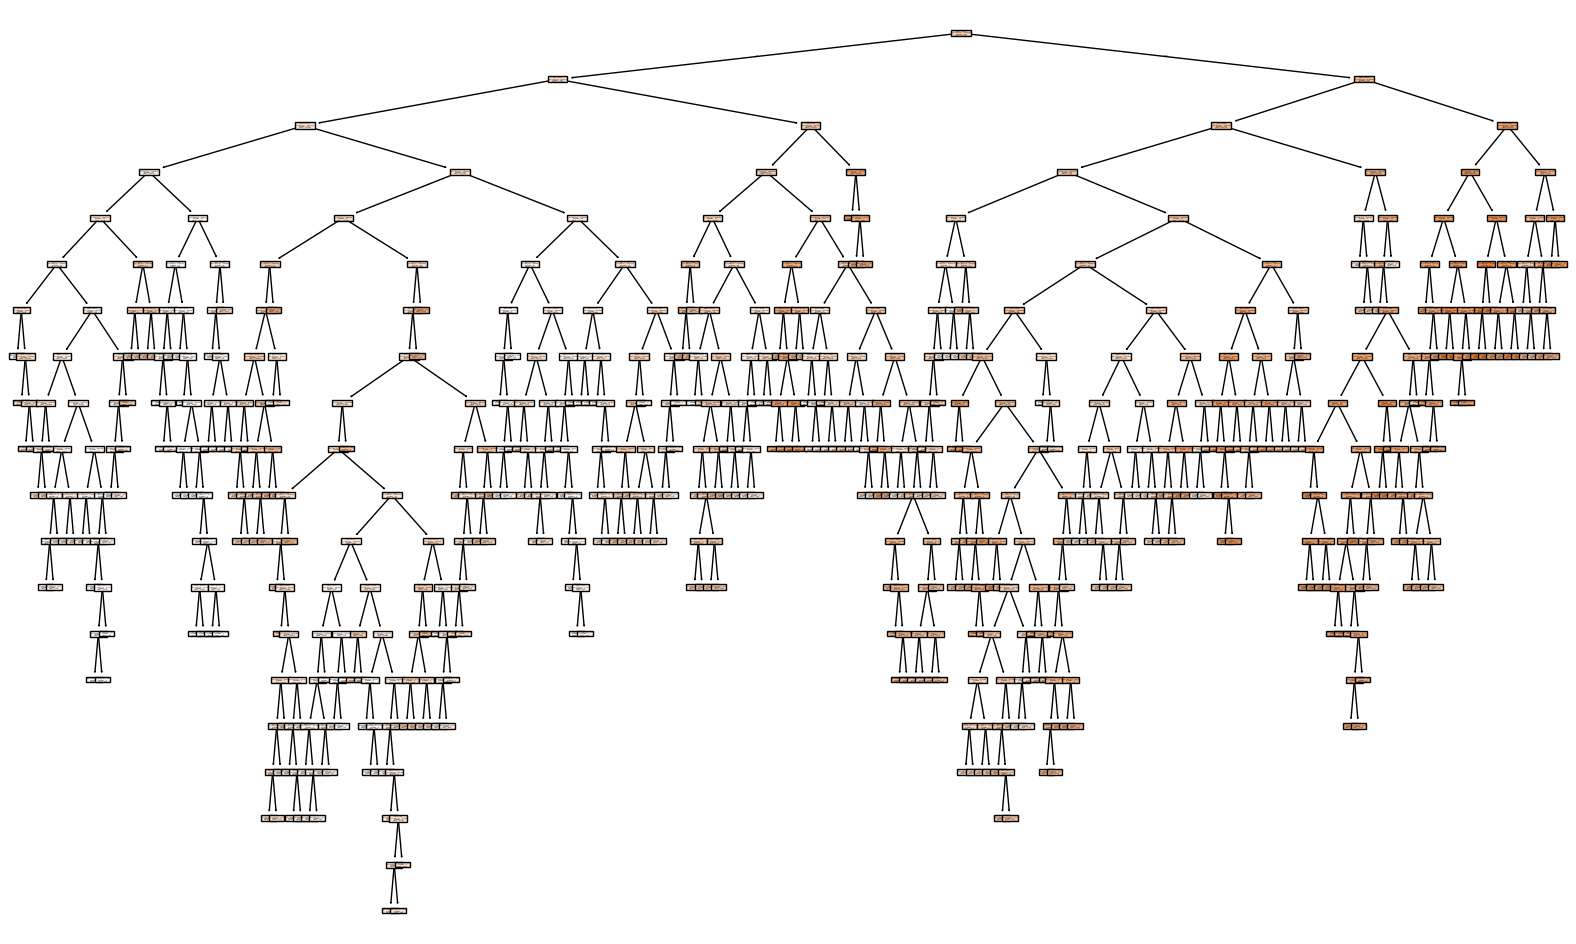

In [6]:
# lets visualize the regression tree
plt.figure(figsize=(20,12))
plot_tree(regressor, feature_names=X.columns, filled=True)
plt.show()

In [7]:
# fine tuning the regressor using grid search
from sklearn.model_selection import GridSearchCV
# Define the parameter grid
param_grid = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}
# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=regressor, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
# Fit the grid search to the data
grid_search.fit(X_train, y_train)
# Print the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Score (MSE):", -grid_search.best_score_)   

# fit the regressor with best parameters
best_regressor = grid_search.best_estimator_
best_regressor.fit(X_train, y_train)
# Make predictions
y_pred = best_regressor.predict(X_test)
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error after tuning: {mse:.2f}")
print(f"R^2 Score after tuning: {r2:.2f}")

# here what R^2 score indicates how well the model
# explains the variance in the target variable. A score closer to 1 means a better fit.


Best Parameters: {'criterion': 'squared_error', 'max_depth': 5, 'min_samples_split': 10}
Best Cross-validation Score (MSE): 4406.829326644768
Mean Squared Error after tuning: 3434.90
R^2 Score after tuning: 0.35


### Reference
- https://www.studocu.com/in/document/vignan-institute-of-technology-and-science/machine-learning/id3-decision-tree-example-play-tennis-dataset-analysis/132749538
- https://homepage.cs.uri.edu/faculty/hamel/courses/2018/spring2018/csc581/lecture-notes/31a-decision-trees.pdf
- https://homepage.cs.uri.edu/faculty/hamel/courses/2014/spring2014/csc581/lecture-notes/31-decision-trees.pdf
-https://www.uri.edu/search/?cx=016863979916529535900%3A17qai8akniu&cof=FORID%3A11&q=Decision+Tree&searchsubmit=Search

In [ ]:
from